In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [15]:
df = pd.read_csv("titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [17]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [26]:
# Fill missing values

df['age'] = df['age'].fillna(df['age'].median())

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Check if any missing values remain
print(df.isnull().sum())

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ['sex', 'embarked', 'class', 'who', 'alive']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert True/False columns to 0 and 1
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  embarked  class  who  \
0         0       3    1  22.0      1      0   7.2500         2      2    1   
1         1       1    0  38.0      1      0  71.2833         0      0    2   
2         1       3    0  26.0      0      0   7.9250         2      2    2   
3         1       1    0  35.0      1      0  53.1000         2      0    2   
4         0       3    1  35.0      0      0   8.0500         2      2    1   

   adult_male  alive  alone  
0           1      0      0  
1           0      1      0  
2           0      1      1  
3           0      1      0  
4           1      0      1  


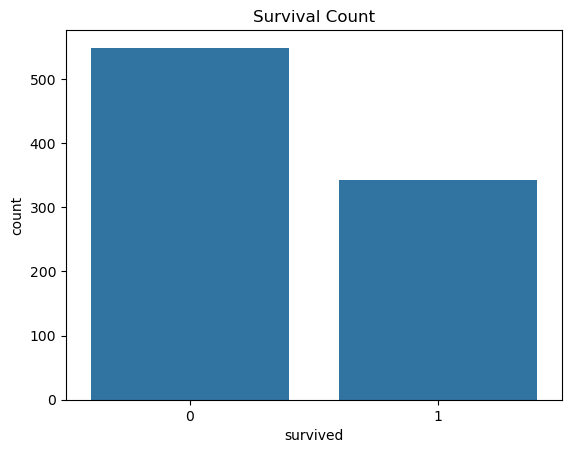

In [28]:
sns.countplot(x='survived', data=df)

plt.title("Survival Count")
plt.show()


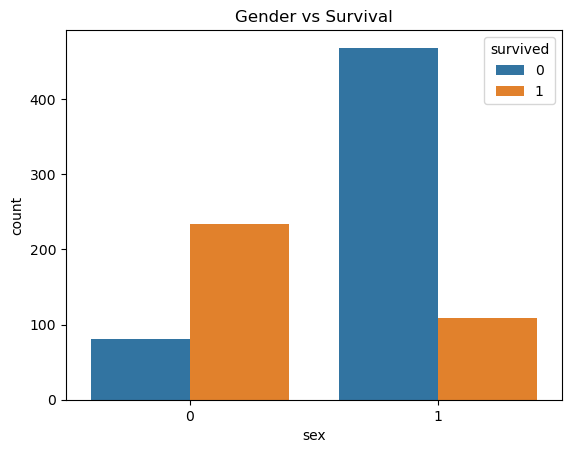

In [29]:
sns.countplot(x='sex', hue='survived', data=df)

plt.title("Gender vs Survival")
plt.show()

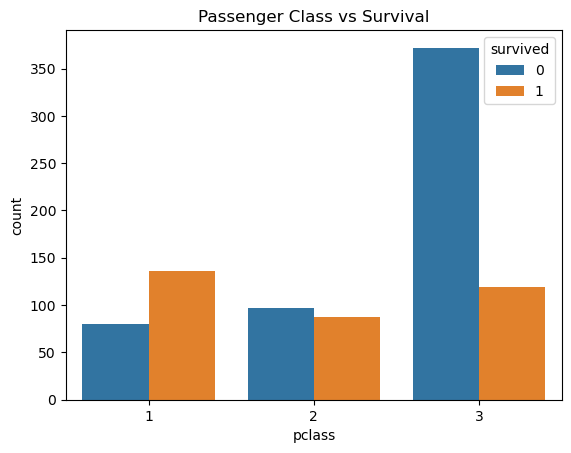

In [30]:
sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Passenger Class vs Survival")
plt.show()

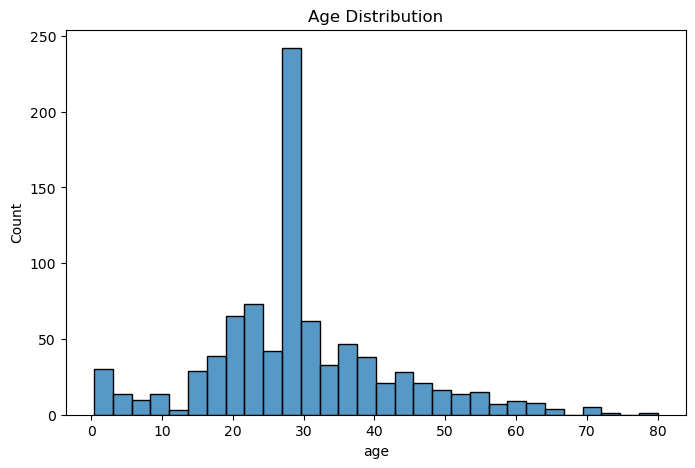

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")

plt.show()


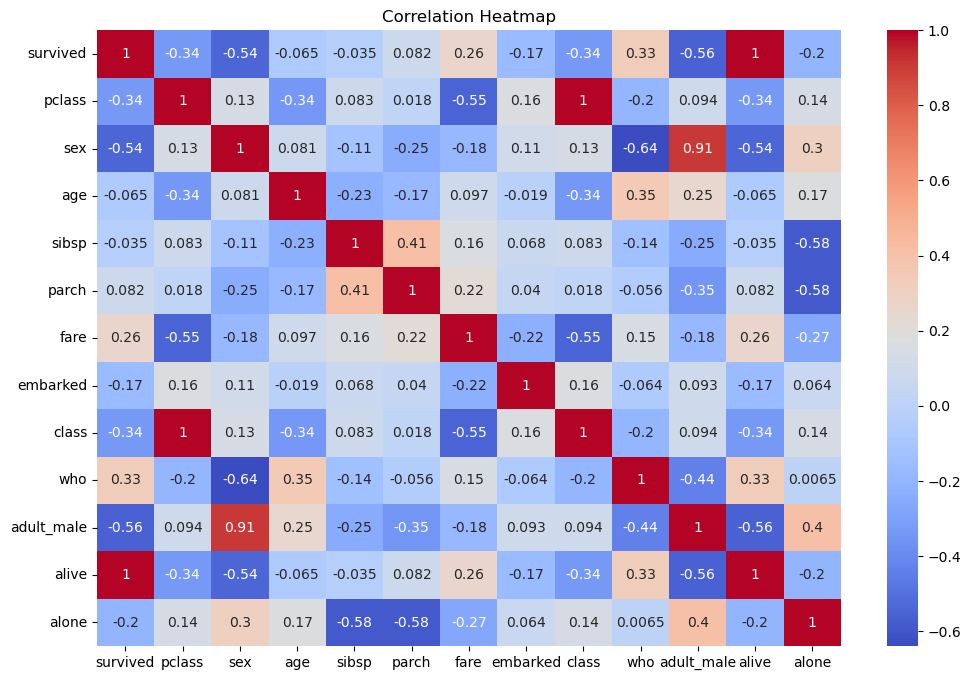

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [34]:
X = df.drop(['survived', 'alive'], axis=1)

y = df['survived']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred1 = lr.predict(X_test)

print("Accuracy =", accuracy_score(y_test, pred1))


Accuracy = 0.8100558659217877


In [38]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred2 = dt.predict(X_test)

print("Accuracy =", accuracy_score(y_test, pred2))

Accuracy = 0.7374301675977654


In [39]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred3 = rf.predict(X_test)

print("Accuracy =", accuracy_score(y_test, pred3))

Accuracy = 0.8268156424581006


In [41]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train, y_train)

pred2 = svm.predict(X_test)

print("SVM Accuracy =", accuracy_score(y_test, pred2))

SVM Accuracy = 0.659217877094972


In [42]:
scores = cross_val_score(lr, X, y, cv=5)

print(scores)

print("Average =", scores.mean())

[0.81564246 0.79775281 0.80898876 0.80337079 0.85393258]
Average = 0.8159374803841567


In [43]:
scores = cross_val_score(dt, X, y, cv=5)

print(scores.mean())

0.7845332998556274


In [44]:
scores = cross_val_score(rf, X, y, cv=5)

print(scores.mean())

0.8092272926997678


In [45]:
scores = cross_val_score(svm, X, y, cv=5)

print(scores)

print("Average Accuracy =", scores.mean())

[0.59217877 0.71348315 0.69101124 0.68539326 0.69101124]
Average Accuracy = 0.674615529470843


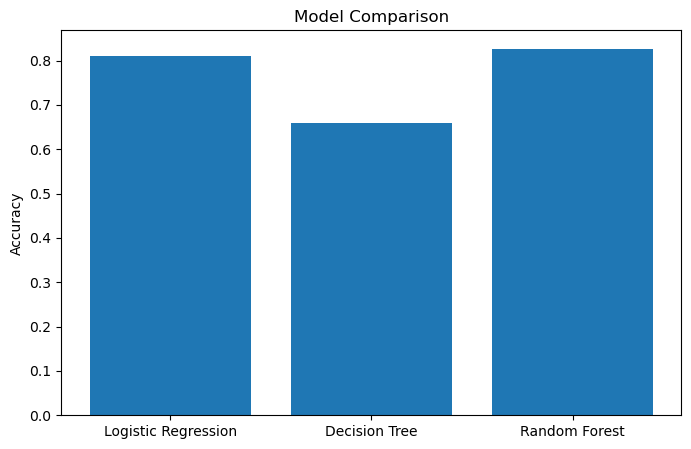

In [46]:
models = ['Logistic Regression','Decision Tree','Random Forest']

accuracy = [
    accuracy_score(y_test, pred1),
    accuracy_score(y_test, pred2),
    accuracy_score(y_test, pred3)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

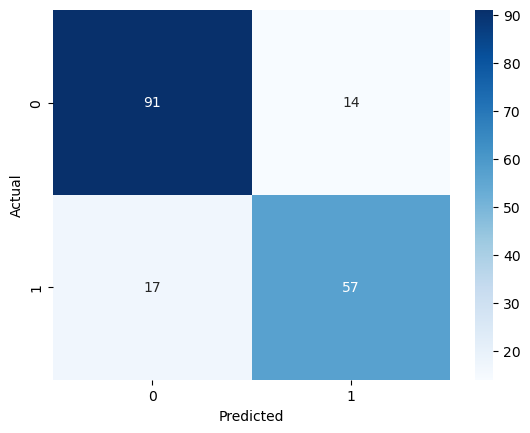

In [47]:
cm = confusion_matrix(y_test, pred3)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [59]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(lr, X, y, cv=5)

print("Logistic Regression Cross Validation Scores:")
print(lr_scores)

print("Average Accuracy:", lr_scores.mean()) 

Logistic Regression Cross Validation Scores:
[0.81564246 0.79775281 0.80898876 0.80337079 0.85393258]
Average Accuracy: 0.8159374803841567


In [60]:
rf_scores = cross_val_score(rf, X, y, cv=5)

print("Random Forest Cross Validation Scores:")
print(rf_scores)

print("Average Accuracy:", rf_scores.mean())

Random Forest Cross Validation Scores:
[0.7877095  0.79775281 0.85393258 0.76966292 0.83707865]
Average Accuracy: 0.8092272926997678


In [61]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(dt, X, y, cv=5)

print("Decision Tree Cross Validation Scores:")
print(dt_scores)

print("Average Accuracy:", dt_scores.mean())

Decision Tree Cross Validation Scores:
[0.76536313 0.78089888 0.81460674 0.76404494 0.79775281]
Average Accuracy: 0.7845332998556274


In [58]:
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [50]:
print(X.columns.tolist())

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']


In [52]:
sample = [[
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    travel_class,
    who,
    adult_male,
    alone
]]



In [54]:
print("Titanic Survival Prediction")

pclass = int(input("Passenger Class (1,2,3): "))
sex = int(input("Sex (0=Female, 1=Male): "))
age = float(input("Age: "))
sibsp = int(input("Siblings/Spouse: "))
parch = int(input("Parents/Children: "))
fare = float(input("Fare: "))
embarked = int(input("Embarked (0=C, 1=Q, 2=S): "))
travel_class = int(input("Class (0=First, 1=Second, 2=Third): "))
who = int(input("Who (0=Child, 1=Man, 2=Woman): "))
adult_male = int(input("Adult Male (0=No, 1=Yes): "))
alone = int(input("Alone (0=No, 1=Yes): "))

sample = pd.DataFrame({
    'pclass': [pclass],
    'sex': [sex],
    'age': [age],
    'sibsp': [sibsp],
    'parch': [parch],
    'fare': [fare],
    'embarked': [embarked],
    'class': [travel_class],
    'who': [who],
    'adult_male': [adult_male],
    'alone': [alone]
})

prediction = rf.predict(sample)
if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Titanic Survival Prediction


Passenger Class (1,2,3):  3
Sex (0=Female, 1=Male):  1
Age:  35
Siblings/Spouse:  0
Parents/Children:  0
Fare:  8
Embarked (0=C, 1=Q, 2=S):  2
Class (0=First, 1=Second, 2=Third):  2
Who (0=Child, 1=Man, 2=Woman):  1
Adult Male (0=No, 1=Yes):  1
Alone (0=No, 1=Yes):  1


Passenger Did Not Survive


# Machine Learning Capstone Project Summary

## Titanic Survival Prediction Using Machine Learning

### Problem Statement

The objective of this project was to develop a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information such as passenger class, gender, age, fare, family members traveling together, and embarkation details. This is a binary classification problem where the target variable is **survived** (0 = Did Not Survive, 1 = Survived).

### Approach

The project followed a complete end-to-end machine learning workflow.

1. **Data Collection:** The Titanic dataset was loaded into a pandas DataFrame.
2. **Data Exploration (EDA):** The dataset was explored using statistical summaries and visualizations. Count plots, histograms, and a correlation heatmap were created to understand the distribution of features and their relationship with survival.
3. **Data Preprocessing:** Missing values in the **age** and **embarked** columns were handled using the median and mode, respectively. Categorical variables such as **sex**, **class**, **embarked**, **who**, and **alive** were converted into numerical values using Label Encoding. Boolean columns (**adult_male** and **alone**) were converted into integer values. The **alive** column was removed before training because it duplicated the target variable.
4. **Model Building:** The dataset was divided into training and testing sets using an 80:20 train-test split. Three machine learning models were trained and evaluated:

   * Logistic Regression
   * Support Vector Machine (SVM)
   * Random Forest Classifier
5. **Model Evaluation:** The models were evaluated using Accuracy Score, Confusion Matrix, Classification Report, and 5-fold Cross-Validation. A bar chart was used to compare the performance of all models.
6. **Deployment:** A simple Python Command-Line Interface (CLI) application was developed to allow users to enter passenger details and predict whether the passenger would survive.

### Results

The exploratory data analysis revealed that female passengers and first-class passengers had a higher survival rate than male passengers and third-class passengers. Among the three machine learning algorithms, the Random Forest Classifier achieved the highest prediction accuracy and produced the most reliable results during cross-validation. Logistic Regression provided a strong baseline model, while Support Vector Machine also achieved competitive performance.

### Improvements

The project can be enhanced in several ways. Feature engineering can be applied by creating new features such as family size or title extracted from passenger information. Hyperparameter tuning using GridSearchCV or RandomizedSearchCV could further improve model performance. Additional preprocessing techniques such as feature scaling and one-hot encoding can also be explored. Finally, instead of a command-line interface, the model can be deployed as a web application using Flask or Streamlit, allowing users to interact with the prediction model through a graphical interface.

### Conclusion

This project successfully demonstrated the complete machine learning pipeline, from data preprocessing and exploratory data analysis to model training, evaluation, and deployment. Comparing multiple algorithms helped identify the Random Forest Classifier as the best-performing model for predicting Titanic passenger survival. The project highlights the importance of data preprocessing, feature selection, and model evaluation in building accurate and reliable machine learning solutions.


In [64]:
print("Logistic Regression Accuracy: {:.2f}%".format(accuracy_score(y_test, pred1)*100))

print("Decision Tree: {:.2f}%".format(accuracy_score(y_test, pred2)*100))

print("Random Forest Accuracy: {:.2f}%".format(accuracy_score(y_test, pred3)*100))

Logistic Regression Accuracy: 81.01%
Decision Tree: 65.92%
Random Forest Accuracy: 82.68%


In [66]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Cross Validation Accuracy": [
        lr_scores.mean(),
        dt_scores.mean(),
        rf_scores.mean()
    ]
})

comparison = comparison.sort_values(by="Cross Validation Accuracy", ascending=False)

print(comparison)

                 Model  Cross Validation Accuracy
0  Logistic Regression                   0.815937
2        Random Forest                   0.809227
1        Decision Tree                   0.784533


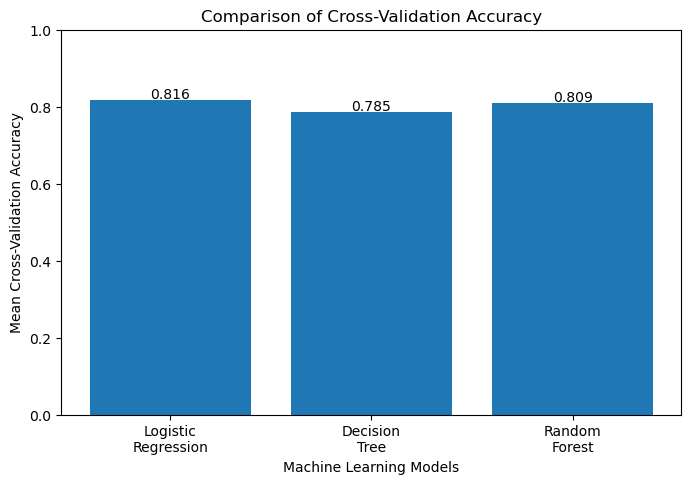

In [68]:
import matplotlib.pyplot as plt

# Mean Cross Validation Scores
cv_scores = [
    lr_scores.mean(),
    dt_scores.mean(),
    rf_scores.mean()
]

models = [
    "Logistic\nRegression",
    "Decision\nTree",
    "Random\nForest"
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, cv_scores)

plt.title("Comparison of Cross-Validation Accuracy")
plt.xlabel("Machine Learning Models")
plt.ylabel("Mean Cross-Validation Accuracy")

# Display values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.005,
             f"{height:.3f}",
             ha='center',
             fontsize=10)

plt.ylim(0, 1)

plt.show()